In [81]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
df=pd.read_csv(r"A:\Daily_challenges\day_01\data\food_orders_new_delhi (1).csv")

In [6]:
df.head()

,Order ID,Customer ID,Restaurant ID,Order Date and Time,Delivery Date and Time,Order Value,Delivery Fee,Payment Method,Discounts and Offers,Commission Fee,Payment Processing Fee,Refunds/Chargebacks
0,1,C8270,R2924,2024-02-01 01:11:52,2024-02-01 02:39:52,1914,0,Credit Card,5% on App,150,47,0
1,2,C1860,R2054,2024-02-02 22:11:04,2024-02-02 22:46:04,986,40,Digital Wallet,10%,198,23,0
2,3,C6390,R2870,2024-01-31 05:54:35,2024-01-31 06:52:35,937,30,Cash on Delivery,15% New User,195,45,0
3,4,C6191,R2642,2024-01-16 22:52:49,2024-01-16 23:38:49,1463,50,Cash on Delivery,NaN,146,27,0
4,5,C6734,R2799,2024-01-29 01:19:30,2024-01-29 02:48:30,1992,30,Cash on Delivery,50 off Promo,130,50,0


In [8]:
df.shape

(1000, 12)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Order ID                1000 non-null   int64
 1   Customer ID             1000 non-null   str  
 2   Restaurant ID           1000 non-null   str  
 3   Order Date and Time     1000 non-null   str  
 4   Delivery Date and Time  1000 non-null   str  
 5   Order Value             1000 non-null   int64
 6   Delivery Fee            1000 non-null   int64
 7   Payment Method          1000 non-null   str  
 8   Discounts and Offers    815 non-null    str  
 9   Commission Fee          1000 non-null   int64
 10  Payment Processing Fee  1000 non-null   int64
 11  Refunds/Chargebacks     1000 non-null   int64
dtypes: int64(6), str(6)
memory usage: 93.9 KB


In [10]:
df.describe()

,Order ID,Order Value,Delivery Fee,Commission Fee,Payment Processing Fee,Refunds/Chargebacks
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,1053.969000,28.620000,126.99000,29.832000,28.300000
std,288.819436,530.975339,16.958278,43.06405,11.627165,49.614228
min,1.000000,104.000000,0.000000,50.00000,10.000000,0.000000
25%,250.750000,597.750000,20.000000,90.00000,20.000000,0.000000
50%,500.500000,1038.500000,30.000000,127.00000,30.000000,0.000000
75%,750.250000,1494.000000,40.000000,164.00000,40.000000,50.000000
max,1000.000000,1995.000000,50.000000,200.00000,50.000000,150.000000


In [12]:
df.columns

Index(['Order ID', 'Customer ID', 'Restaurant ID', 'Order Date and Time',
       'Delivery Date and Time', 'Order Value', 'Delivery Fee',
       'Payment Method', 'Discounts and Offers', 'Commission Fee',
       'Payment Processing Fee', 'Refunds/Chargebacks'],
      dtype='str')

In [13]:
df.isnull().sum()

Order ID                    0
Customer ID                 0
Restaurant ID               0
Order Date and Time         0
Delivery Date and Time      0
Order Value                 0
Delivery Fee                0
Payment Method              0
Discounts and Offers      185
Commission Fee              0
Payment Processing Fee      0
Refunds/Chargebacks         0
dtype: int64

In [16]:
df['Order Date and Time'].dtype

<StringDtype(storage='python', na_value=nan)>

In [17]:
df['Order Date and Time']=pd.to_datetime(df['Order Date and Time'])#converting data type

In [19]:
df['Order Date and Time'].dtypes

dtype('<M8[us]')

In [20]:
df['Order Date and Time'].min()

Timestamp('2024-01-01 02:12:47')

In [22]:
df['Order Date and Time'].max()

Timestamp('2024-02-07 23:56:12')

In [24]:
df['Period']=np.where(df['Order Date and Time'].dt.month==1,"Previous Period","Current Period")

In [26]:
df['Period'].value_counts()

Period
Previous Period    805
Current Period     195
Name: count, dtype: int64

In [27]:
#first business question 
# did business gets more orders?
orders=df.groupby('Period')['Order ID'].count()
orders

Period
Current Period     195
Previous Period    805
Name: Order ID, dtype: int64

In [45]:
#now calculating the order growth
previous_ord=orders["Previous Period"]
current_ord=orders["Current Period"]
order_growth=(round(((current_ord-previous_ord)/previous_ord)*100,2))
print("ord growth:",order_growth)

ord growth: -75.78


In [36]:
#aggregation of revenue
revenue=df.groupby("Period")["Order Value"].sum()
revenue

Period
Current Period     207291
Previous Period    846678
Name: Order Value, dtype: int64

In [43]:
#calculation revenue growth
previous_revenue=revenue["Previous Period"]
current_revenue=revenue["Current Period"]
revenue_growth=(round(((current_revenue-previous_revenue)/previous_revenue)*100,2))
print("revenue growth:",revenue_growth)

revenue growth: -75.52


In [40]:
#average order value
aov=revenue/orders
print(aov)

Period
Current Period     1063.030769
Previous Period    1051.773913
dtype: float64


In [44]:
previous_aov=aov['Previous Period']
current_aov=aov['Current Period']
aov_growth=(round(((current_aov-previous_aov)/previous_aov)*100,2))
print(aov_growth)

1.07


In [46]:
#comparison
summary=pd.DataFrame({"Orders":orders,"Revenue":revenue,"AOV":aov})
summary


,Orders,Revenue,AOV
Period,,,
Current Period,195,207291,1063.030769
Previous Period,805,846678,1051.773913


In [47]:
df["Discounts and Offers"].value_counts()

Discounts and Offers
10%             233
50 off Promo    201
15% New User    198
5% on App       183
Name: count, dtype: int64

In [48]:
#cleaning the dicount column
def Extract_discount(val):
    val=str(val)
    if "off" in val:
        return float(val.split()[0])
    elif "%" in val:
        return float(val.split("%")[0])
    else:
        return 0
df["Discount value"]=df["Discounts and Offers"].apply(Extract_discount)

In [50]:
#checking 
df[
    [
        "Order Value",
        "Discounts and Offers",
        "Discount value"
    ]
].head(20)

,Order Value,Discounts and Offers,Discount value
0,1914,5% on App,5.0
1,986,10%,10.0
2,937,15% New User,15.0
3,1463,NaN,0.0
4,1992,50 off Promo,50.0
5,439,10%,10.0
6,303,5% on App,5.0
7,260,10%,10.0
8,1663,5% on App,5.0
9,491,10%,10.0


In [57]:
#distinguishing the amount vs percentage
def calculate_amount(row):
    offer=str(row["Discounts and Offers"])
    order_value=row["Order Value"]

    if "%" in offer:
        percentage=float(offer.split("%")[0])
        return order_value*percentage/100#to get discount amount
    elif "off" in offer:
        return float(offer.split()[0])
    else:
        return 0
df["Discount Amount"]=df.apply(calculate_amount,axis=1)
df.head(10)

,Order ID,Customer ID,Restaurant ID,Order Date and Time,Delivery Date and Time,Order Value,Delivery Fee,Payment Method,Discounts and Offers,Commission Fee,Payment Processing Fee,Refunds/Chargebacks,Period,Discount value,Discount Amount
0,1,C8270,R2924,2024-02-01 01:11:52,2024-02-01 02:39:52,1914,0,Credit Card,5% on App,150,47,0,Current Period,5.0,95.70
1,2,C1860,R2054,2024-02-02 22:11:04,2024-02-02 22:46:04,986,40,Digital Wallet,10%,198,23,0,Current Period,10.0,98.60
2,3,C6390,R2870,2024-01-31 05:54:35,2024-01-31 06:52:35,937,30,Cash on Delivery,15% New User,195,45,0,Previous Period,15.0,140.55
3,4,C6191,R2642,2024-01-16 22:52:49,2024-01-16 23:38:49,1463,50,Cash on Delivery,NaN,146,27,0,Previous Period,0.0,0.00
4,5,C6734,R2799,2024-01-29 01:19:30,2024-01-29 02:48:30,1992,30,Cash on Delivery,50 off Promo,130,50,0,Previous Period,50.0,50.00
5,6,C7265,R2777,2024-01-25 04:36:52,2024-01-25 05:27:52,439,20,Cash on Delivery,10%,92,27,150,Previous Period,10.0,43.90
6,7,C1466,R2457,2024-01-12 23:55:48,2024-01-13 00:48:48,303,30,Digital Wallet,5% on App,144,12,50,Previous Period,5.0,15.15
7,8,C5426,R2978,2024-01-26 22:46:24,2024-01-27 00:36:24,260,0,Credit Card,10%,55,19,0,Previous Period,10.0,26.00
8,9,C6578,R2877,2024-01-02 18:29:59,2024-01-02 20:23:59,1663,40,Cash on Delivery,5% on App,116,48,0,Previous Period,5.0,83.15
9,10,C9322,R2161,2024-01-05 00:50:19,2024-01-05 02:10:19,491,40,Digital Wallet,10%,189,10,0,Previous Period,10.0,49.10


In [58]:
# caluculate discount rate
df["Discount rate"]=(df["Discount Amount"]/df["Order Value"])*100

In [60]:
df[
    [
        "Order Value",
        "Discount Amount",
        "Discount rate"
    ]
].head()


,Order Value,Discount Amount,Discount rate
0,1914,95.70,5.00000
1,986,98.60,10.00000
2,937,140.55,15.00000
3,1463,0.00,0.00000
4,1992,50.00,2.51004


In [61]:
#comparing dicounts between period
discount_analysis=df.groupby("Period").agg(
    total_discount=("Discount Amount","sum"),
    Avg_discount=("Discount Amount","mean"),
    avg_Discount_rate=("Discount rate","mean")
)
discount_analysis

,total_discount,Avg_discount,avg_Discount_rate
Period,,,
Current Period,14037.65,71.987949,7.273810
Previous Period,60252.20,74.847453,7.746855


In [62]:
bins=[0,199,399,599,799,float("inf")]
labels=[
    "₹0-199",
    "₹200-399",
    "₹400-599",
    "₹600-799",
    "₹800+"
]
df["Order Value Bucket"]=pd.cut(df["Order Value"],bins=bins,labels=labels)

In [63]:
df["Order Value Bucket"].value_counts()

Order Value Bucket
₹800+       652
₹400-599    111
₹200-399    101
₹600-799     95
₹0-199       41
Name: count, dtype: int64

In [65]:
#compare order mix
order_mix=pd.crosstab(df["Order Value Bucket"],
                     df["Period"])
print(order_mix)

Period              Current Period  Previous Period
Order Value Bucket                                 
₹0-199                           6               35
₹200-399                        20               81
₹400-599                        23               88
₹600-799                        18               77
₹800+                          128              524


In [66]:
#calculate percentage mix
order_mix_percentage=pd.crosstab(
    df["Order Value Bucket"],
    df["Period"],
    normalize="columns"
)*100
order_mix_percentage

Period,Current Period,Previous Period
Order Value Bucket,,
₹0-199,3.076923,4.347826
₹200-399,10.256410,10.062112
₹400-599,11.794872,10.931677
₹600-799,9.230769,9.565217
₹800+,65.641026,65.093168


In [73]:
#analysing order around ₹99
low_value_order=df[df["Order Value"]<=99]
print(low_value_order)

Empty DataFrame
Columns: [Order ID, Customer ID, Restaurant ID, Order Date and Time, Delivery Date and Time, Order Value, Delivery Fee, Payment Method, Discounts and Offers, Commission Fee, Payment Processing Fee, Refunds/Chargebacks, Period, Discount value, Discount Amount, Discount rate, Order Value Bucket]
Index: []


In [75]:
low_value_order.groupby("Period").agg(
    orders=("Order ID","count"),
    revenue=("Order Value","sum"),
    AOV=("Order Value","mean"),
    Discount=("Discount Amount","sum")
)
print("no low order value is contributed to decline in growth ")

no low order value is contributed to decline in growth 


In [76]:
df["Has Discount"]=df["Discount Amount"] > 0

In [78]:
promo_analysis=df.groupby(["Period","Has Discount"]).agg(
    Orders=("Order ID", "count"),
    Revenue=("Order Value", "sum"),
    AOV=("Order Value", "mean"),
    Discount=("Discount Amount", "sum")
)
promo_analysis

Orders  Revenue          AOV  Discount
Period          Has Discount                                        
Current Period  False             39    41715  1069.615385      0.00
                True             156   165576  1061.384615  14037.65
Previous Period False            146   152142  1042.068493      0.00
                True             659   694536  1053.924127  60252.20

In [79]:
df.groupby("Has Discount")["Order Value"].mean()

Has Discount
False    1047.875676
True     1055.352147
Name: Order Value, dtype: float64

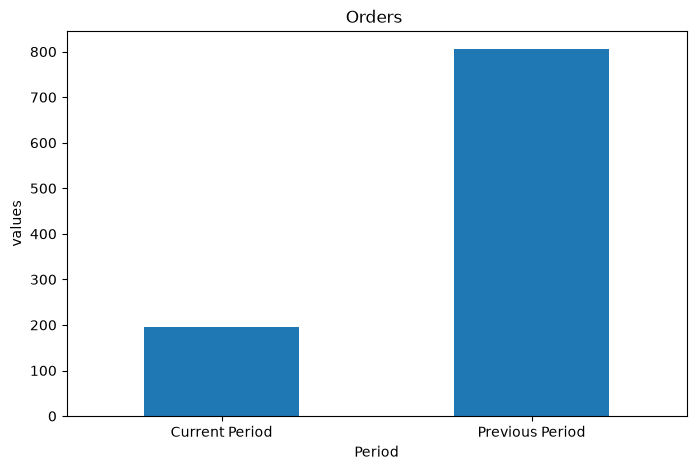

In [97]:
summary["Orders"].plot(
    kind="bar",
    figsize=(8,5)
)
plt.title("Orders ")
plt.ylabel("values")
plt.xticks(rotation=0)
plt.show()

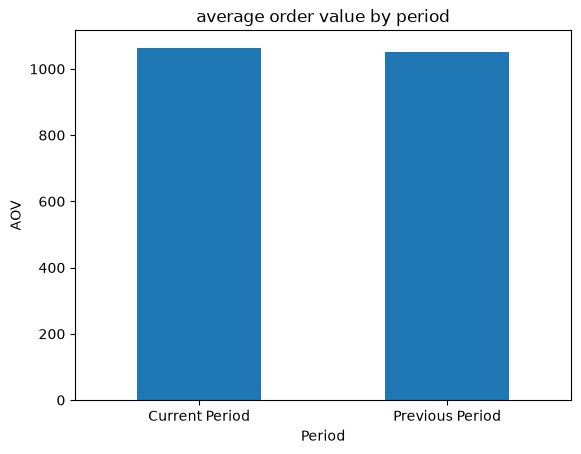

In [90]:
summary["AOV"].plot(
    kind="bar",
)
plt.title("average order value by period")
plt.ylabel("AOV")
plt.xticks(rotation=0)
plt.show()

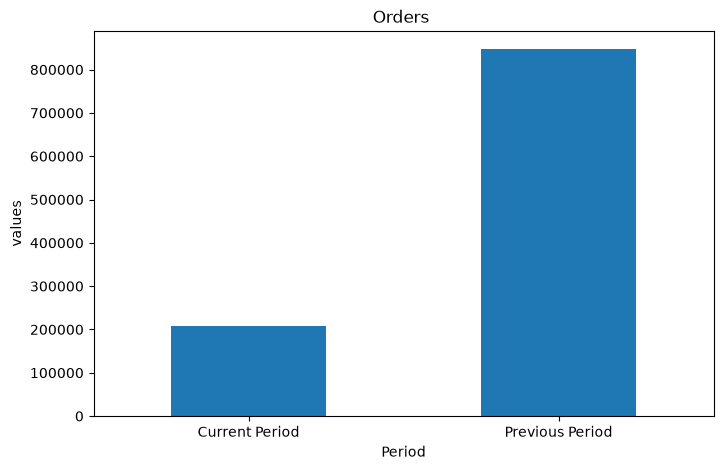

In [98]:
summary["Revenue"].plot(
    kind="bar",
    figsize=(8,5)
)
plt.title("Orders ")
plt.ylabel("values")
plt.xticks(rotation=0)
plt.show()

In [101]:
df.groupby("Has Discount").agg(
    Orders=("Order ID", "count"),
    Avg_Order_Value=("Order Value", "mean"),
    Avg_Discount=("Discount Amount", "mean")
)

,Orders,Avg_Order_Value,Avg_Discount
Has Discount,,,
False,185,1047.875676,0.00000
True,815,1055.352147,91.15319


In [100]:
df.groupby("Period").agg(
    Orders=("Order ID", "count"),
    Revenue=("Order Value", "sum"),
    AOV=("Order Value", "mean"),
    Discount=("Discount Amount", "mean")
)

,Orders,Revenue,AOV,Discount
Period,,,,
Current Period,195,207291,1063.030769,71.987949
Previous Period,805,846678,1051.773913,74.847453


In [102]:
#calculate the platform fee
df["Platform_revenue"]=df["Commission Fee"]
df["total cost"]=(df["Delivery Fee"]+df["Payment Processing Fee"]+df["Discount Amount"])

In [103]:
df["profit"]=(df["Platform_revenue"]- df["total cost"])

In [105]:
profit_analysis=df.groupby("Period").agg(
    Orders=("Order ID", "count"),
    Platform_Revenue=("Platform_revenue", "sum"),
    Total_Cost=("total cost", "sum"),
    Profit=("profit", "sum")
)
profit_analysis

,Orders,Platform_Revenue,Total_Cost,Profit
Period,,,,
Current Period,195,24343,25446.65,-1103.65
Previous Period,805,102647,107295.20,-4648.20


In [107]:
profit_analysis["Profit_Per_Order"] = (
    profit_analysis["Profit"]
    / profit_analysis["Orders"]
)

profit_analysis

,Orders,Platform_Revenue,Total_Cost,Profit,Profit_Per_Order
Period,,,,,
Current Period,195,24343,25446.65,-1103.65,-5.659744
Previous Period,805,102647,107295.20,-4648.20,-5.774161
